# Vasicek estimation and affine term-premium calibration

This notebook reproduces the full workflow:

1. Load the monthly short-rate and Treasury-yield dataset.
2. Estimate the short-rate dynamics under the physical measure \(P\) with an AR(1).
3. Map the AR(1) into continuous-time Vasicek parameters \((\kappa_P, \theta_P, \sigma)\).
4. Calibrate an affine market price of risk,
   \[
   \lambda(r_t) = \lambda_0 + \lambda_1 r_t,
   \]
   using two criteria:
   - level SSE across the 2Y, 5Y, and 10Y yields
   - ratio SSE across the same tenors
5. Produce LaTeX tables, PDF figures, and a CSV file with the fitted series.

The data are already stored in the project folder, so the notebook can run offline.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4.8)
plt.rcParams["axes.grid"] = True



## Load and inspect the data

All yields are stored in decimal form. For example, 5.50% is recorded as 0.055.


In [5]:
df = pd.read_csv("fed_vasicek_data.csv", parse_dates=["date"]).set_index("date")
sample = df[df.index >= "2000-01-31"].copy()

print("Sample start:", sample.index.min().date())
print("Sample end  :", sample.index.max().date())
print("Number of observations:", len(sample))
sample.head()

Sample start: 2000-01-31
Sample end  : 2026-04-10
Number of observations: 316


,fed,y2,y5,y10
date,,,,
2000-01-31,0.0550,0.0659,0.0668,0.0667
2000-02-29,0.0575,0.0652,0.0660,0.0641
2000-03-31,0.0600,0.0648,0.0631,0.0600
2000-04-28,0.0600,0.0668,0.0654,0.0621
2000-05-31,0.0650,0.0667,0.0652,0.0627


In [6]:
sample.describe().T

,count,mean,std,min,25%,50%,75%,max
fed,316.0,0.021179,0.020007,0.0025,0.002500,0.01375,0.040000,0.0650
y2,316.0,0.022538,0.017581,0.0011,0.006275,0.01820,0.038000,0.0668
y5,316.0,0.027567,0.014746,0.0020,0.015375,0.02670,0.039525,0.0668
y10,316.0,0.032982,0.012888,0.0053,0.022175,0.03415,0.042825,0.0667


## Estimate the short-rate dynamics under \(P\)

We estimate the discrete-time AR(1):
\[
r_t = c + \phi r_{t-1} + \varepsilon_t.
\]

Using the exact discretization of the Vasicek model,
\[
dr_t = \kappa_P(\theta_P-r_t)dt + \sigma dW_t^P,
\]
the mapping from the AR(1) to continuous time is:
\[
\phi = e^{-\kappa_P \Delta t}, \qquad
c = \theta_P(1-\phi).
\]

Hence,
\[
\kappa_P = -\frac{\ln \phi}{\Delta t}, \qquad
\theta_P = \frac{c}{1-\phi}.
\]


In [7]:
r = sample["fed"]
X = sm.add_constant(r.shift(1).dropna().values)
Y = r.iloc[1:].values
ols = sm.OLS(Y, X).fit()

c, phi = ols.params
dt = 1 / 12
kappa_p = -np.log(phi) / dt
theta_p = c / (1 - phi)

sigma_eps = np.sqrt(np.sum(ols.resid**2) / (len(ols.resid) - 2))
sigma_p = sigma_eps * np.sqrt(2 * kappa_p / (1 - phi**2))

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 2.565e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          2.32e-302
Time:                        12:02:47   Log-Likelihood:                 1482.5
No. Observations:                 315   AIC:                            -2961.
Df Residuals:                     313   BIC:                            -2954.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.810      0.4

In [8]:
# Delta-method standard errors for kappa_P and theta_P
cov_beta = ols.cov_params()

# kappa(phi) = -ln(phi)/dt
dkappa_dc = 0.0
dkappa_dphi = -1 / (dt * phi)
grad_kappa = np.array([dkappa_dc, dkappa_dphi])

# theta(c,phi) = c / (1-phi)
dtheta_dc = 1 / (1 - phi)
dtheta_dphi = c / (1 - phi) ** 2
grad_theta = np.array([dtheta_dc, dtheta_dphi])

se_kappa = float(np.sqrt(grad_kappa @ cov_beta @ grad_kappa))
se_theta = float(np.sqrt(grad_theta @ cov_beta @ grad_theta))

ar_table = pd.DataFrame({
    "Parameter": ["const", "phi", "R2", "N"],
    "Estimate": [ols.params[0], ols.params[1], ols.rsquared, len(Y)],
    "Std. error": [ols.bse[0], ols.bse[1], np.nan, np.nan],
    "t-stat": [ols.tvalues[0], ols.tvalues[1], np.nan, np.nan],
})

vasicek_p_table = pd.DataFrame({
    "Parameter": [r"$\kappa_P$", r"$\theta_P$", r"$\sigma$"],
    "Estimate": [kappa_p, theta_p, sigma_p],
    "Std. error": [se_kappa, se_theta, np.nan],
})

display(ar_table)
display(vasicek_p_table)

,Parameter,Estimate,Std. error,t-stat
0,const,0.000146,0.000180,0.810457
1,phi,0.990471,0.006185,160.152568
2,R2,0.987944,NaN,NaN
3,N,315.000000,NaN,NaN


,Parameter,Estimate,Std. error
0,$\kappa_P$,0.114900,0.074929
1,$\theta_P$,0.015297,0.013512
2,$\sigma$,0.007636,NaN


## Define the Vasicek pricing functions under \(Q\)

With an affine market price of risk
$
\lambda(r_t)=\lambda_0+\lambda_1 r_t,
$
the risk-neutral Vasicek parameters are
$
\kappa_Q = \kappa_P + \sigma \lambda_1,
\qquad
\theta_Q = \frac{\kappa_P\theta_P - \sigma \lambda_0}{\kappa_Q}.
$

For maturity \(\tau\), the zero-coupon bond price is
$
P(t,t+\tau)=A(\tau)e^{-B(\tau)r_t},
$
with
$
B(\tau)=\frac{1-e^{-\kappa_Q \tau}}{\kappa_Q}.
$

The corresponding continuously-compounded yield is
$
y(t,\tau)=\frac{-\log A(\tau)+B(\tau)r_t}{\tau}.
$


In [9]:
def vasicek_AB(kappa, theta, sigma, tau):
    B = (1.0 - np.exp(-kappa * tau)) / kappa
    A = np.exp((theta - sigma**2 / (2 * kappa**2)) * (B - tau) - sigma**2 * B**2 / (4 * kappa))
    return A, B

def vasicek_yield(r_now, kappa, theta, sigma, tau):
    A, B = vasicek_AB(kappa, theta, sigma, tau)
    return (-np.log(A) + B * np.asarray(r_now)) / tau

def q_params_from_lambda(lambda0, lambda1, kappa_p, theta_p, sigma):
    kappa_q = kappa_p + sigma * lambda1
    theta_q = (kappa_p * theta_p - sigma * lambda0) / kappa_q
    return kappa_q, theta_q

taus = np.array([2.0, 5.0, 10.0])
Y_obs = sample[["y2", "y5", "y10"]].to_numpy()
r_obs = sample["fed"].to_numpy()

def model_yields_from_lambda(params):
    lambda0, lambda1 = params
    kappa_q, theta_q = q_params_from_lambda(lambda0, lambda1, kappa_p, theta_p, sigma_p)
    if kappa_q <= 1e-6:
        return None
    model = np.column_stack([vasicek_yield(r_obs, kappa_q, theta_q, sigma_p, tau) for tau in taus])
    if np.any(~np.isfinite(model)):
        return None
    return model

def objective_sse(params):
    model = model_yields_from_lambda(params)
    if model is None:
        return 1e12
    return float(np.sum((model - Y_obs) ** 2))

def objective_ratio(params):
    model = model_yields_from_lambda(params)
    if model is None:
        return 1e12
    rel_err = model / np.clip(Y_obs, 1e-8, None) - 1.0
    return float(np.sum(rel_err ** 2))

def multi_start_calibration(obj_fun):
    starts = [
        np.array([0.0, 0.0]),
        np.array([0.0, 2.0]),
        np.array([0.0, -2.0]),
        np.array([0.05, -10.0]),
        np.array([-0.50, 8.0]),
        np.array([0.10, -12.0]),
    ]
    best = None
    for x0 in starts:
        res = minimize(
            obj_fun,
            x0=x0,
            method="Nelder-Mead",
            options={"maxiter": 50000, "xatol": 1e-12, "fatol": 1e-12, "adaptive": True},
        )
        if best is None or res.fun < best.fun:
            best = res
    return best

## Calibrate the affine risk premium

Two calibrations are produced:

- **Level SSE**: minimizes \(\sum (\hat y - y)^2\)
- **Ratio SSE**: minimizes \(\sum (\hat y / y - 1)^2\)

The second criterion gives more weight to low-rate periods.


In [10]:
res_sse = multi_start_calibration(objective_sse)
res_ratio = multi_start_calibration(objective_ratio)

lambda0_sse, lambda1_sse = res_sse.x
lambda0_ratio, lambda1_ratio = res_ratio.x

kappa_q_sse, theta_q_sse = q_params_from_lambda(lambda0_sse, lambda1_sse, kappa_p, theta_p, sigma_p)
kappa_q_ratio, theta_q_ratio = q_params_from_lambda(lambda0_ratio, lambda1_ratio, kappa_p, theta_p, sigma_p)

summary_q = pd.DataFrame({
    "Criterion": ["Level SSE", "Ratio SSE"],
    r"$\lambda_0$": [lambda0_sse, lambda0_ratio],
    r"$\lambda_1$": [lambda1_sse, lambda1_ratio],
    r"$\kappa_Q$": [kappa_q_sse, kappa_q_ratio],
    r"$\theta_Q$": [theta_q_sse, theta_q_ratio],
    "Objective": [res_sse.fun, res_ratio.fun],
})

display(summary_q)

,Criterion,$\lambda_0$,$\lambda_1$,$\kappa_Q$,$\theta_Q$,Objective
0,Level SSE,-0.733423,7.587714,0.172839,0.042571,0.050196
1,Ratio SSE,0.053471,-12.026211,0.023070,0.058489,211.609236


In [12]:
fit_df = sample.copy()
fit_df["fed_fitted_p"] = np.nan
fit_df.loc[fit_df.index[1:], "fed_fitted_p"] = c + phi * fit_df["fed"].shift(1).dropna().values

fit_sse = model_yields_from_lambda(res_sse.x)
fit_ratio = model_yields_from_lambda(res_ratio.x)

fit_df["y2_q_sse"] = fit_sse[:, 0]
fit_df["y5_q_sse"] = fit_sse[:, 1]
fit_df["y10_q_sse"] = fit_sse[:, 2]
fit_df["y2_q_ratio"] = fit_ratio[:, 0]
fit_df["y5_q_ratio"] = fit_ratio[:, 1]
fit_df["y10_q_ratio"] = fit_ratio[:, 2]

fit_df.to_csv("results.csv", index_label="date")
fit_df.head()

,fed,y2,y5,y10,fed_fitted_p,y2_q_sse,y5_q_sse,y10_q_sse,y2_q_ratio,y5_q_ratio,y10_q_ratio
date,,,,,,,,,,,
2000-01-31,0.0550,0.0659,0.0668,0.0667,NaN,0.053049,0.050759,0.048165,0.055042,0.054971,0.054553
2000-02-29,0.0575,0.0652,0.0660,0.0641,0.054622,0.055163,0.052433,0.049354,0.057485,0.057332,0.056785
2000-03-31,0.0600,0.0648,0.0631,0.0600,0.057098,0.057276,0.054107,0.050544,0.059928,0.059693,0.059018
2000-04-28,0.0600,0.0668,0.0654,0.0621,0.059574,0.057276,0.054107,0.050544,0.059928,0.059693,0.059018
2000-05-31,0.0650,0.0667,0.0652,0.0627,0.059574,0.061504,0.057455,0.052923,0.064815,0.064415,0.063483


In [13]:
def rmse_bp(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)) * 10000)

def rel_rmse_pct(a, b):
    return float(np.sqrt(np.mean(((a / np.clip(b, 1e-8, None)) - 1.0) ** 2)) * 100)

fit_metrics = pd.DataFrame({
    "Criterion": ["Level SSE", "Ratio SSE"],
    "RMSE 2Y (bp)": [rmse_bp(fit_df["y2_q_sse"], fit_df["y2"]), rmse_bp(fit_df["y2_q_ratio"], fit_df["y2"])],
    "RMSE 5Y (bp)": [rmse_bp(fit_df["y5_q_sse"], fit_df["y5"]), rmse_bp(fit_df["y5_q_ratio"], fit_df["y5"])],
    "RMSE 10Y (bp)": [rmse_bp(fit_df["y10_q_sse"], fit_df["y10"]), rmse_bp(fit_df["y10_q_ratio"], fit_df["y10"])],
    "Relative RMSE 2Y (pct)": [rel_rmse_pct(fit_df["y2_q_sse"], fit_df["y2"]), rel_rmse_pct(fit_df["y2_q_ratio"], fit_df["y2"])],
    "Relative RMSE 5Y (pct)": [rel_rmse_pct(fit_df["y5_q_sse"], fit_df["y5"]), rel_rmse_pct(fit_df["y5_q_ratio"], fit_df["y5"])],
    "Relative RMSE 10Y (pct)": [rel_rmse_pct(fit_df["y10_q_sse"], fit_df["y10"]), rel_rmse_pct(fit_df["y10_q_ratio"], fit_df["y10"])],
})

summary_q["Global RMSE (bp)"] = [
    float(np.mean(fit_metrics.loc[fit_metrics["Criterion"] == "Level SSE", ["RMSE 2Y (bp)", "RMSE 5Y (bp)", "RMSE 10Y (bp)"]].values)),
    float(np.mean(fit_metrics.loc[fit_metrics["Criterion"] == "Ratio SSE", ["RMSE 2Y (bp)", "RMSE 5Y (bp)", "RMSE 10Y (bp)"]].values)),
]

summary_q["Global relative RMSE (pct)"] = [
    float(np.mean(fit_metrics.loc[fit_metrics["Criterion"] == "Level SSE", ["Relative RMSE 2Y (pct)", "Relative RMSE 5Y (pct)", "Relative RMSE 10Y (pct)"]].values)),
    float(np.mean(fit_metrics.loc[fit_metrics["Criterion"] == "Ratio SSE", ["Relative RMSE 2Y (pct)", "Relative RMSE 5Y (pct)", "Relative RMSE 10Y (pct)"]].values)),
]

display(summary_q)
display(fit_metrics)

,Criterion,$\lambda_0$,$\lambda_1$,$\kappa_Q$,$\theta_Q$,Objective,Global RMSE (bp),Global relative RMSE (pct)
0,Level SSE,-0.733423,7.587714,0.172839,0.042571,0.050196,71.747933,93.851593
1,Ratio SSE,0.053471,-12.026211,0.023070,0.058489,211.609236,103.854894,47.217058


,Criterion,RMSE 2Y (bp),RMSE 5Y (bp),RMSE 10Y (bp),Relative RMSE 2Y (pct),Relative RMSE 5Y (pct),Relative RMSE 10Y (pct)
0,Level SSE,56.285888,73.037837,85.920072,142.223077,87.348664,51.983039
1,Ratio SSE,60.034568,104.903811,146.626304,49.411055,45.440817,46.799301


## Export LaTeX tables


In [14]:
ar_table.to_latex("table_ar_estimation.tex", index=False, float_format="%.6f")
vasicek_p_table.to_latex("table_vasicek_p.tex", index=False, escape=False, float_format="%.6f")
summary_q.to_latex("table_q_calibration.tex", index=False, escape=False, float_format="%.6f")
fit_metrics.to_latex("table_fit_metrics.tex", index=False, float_format="%.3f")

print("LaTeX tables written to:", TAB_DIR)

LaTeX tables written to: \mnt\data\vasicek_project_english\tables


## Produce and export the figures


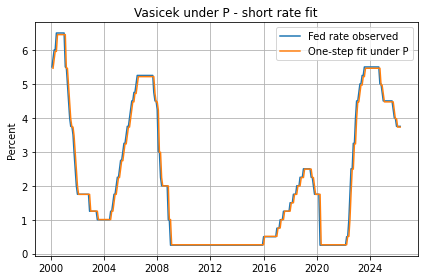

In [15]:
plt.figure()
plt.plot(fit_df.index, fit_df["fed"] * 100, label="Fed rate observed")
plt.plot(fit_df.index[1:], fit_df["fed_fitted_p"].iloc[1:] * 100, label="One-step fit under P")
plt.title("Vasicek under P - short rate fit")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.savefig("fit_short_rate_P.pdf")
plt.show()

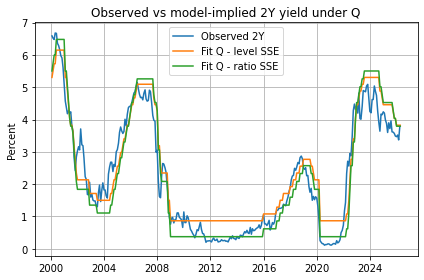

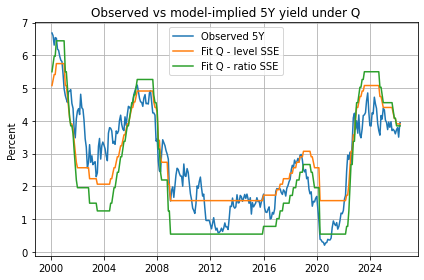

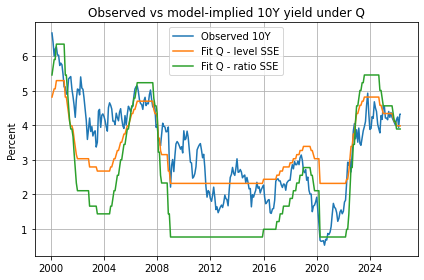

In [16]:
for tenor, col_obs, col_sse, col_ratio in [
    ("2Y", "y2", "y2_q_sse", "y2_q_ratio"),
    ("5Y", "y5", "y5_q_sse", "y5_q_ratio"),
    ("10Y", "y10", "y10_q_sse", "y10_q_ratio"),
]:
    plt.figure()
    plt.plot(fit_df.index, fit_df[col_obs] * 100, label=f"Observed {tenor}")
    plt.plot(fit_df.index, fit_df[col_sse] * 100, label="Fit Q - level SSE")
    plt.plot(fit_df.index, fit_df[col_ratio] * 100, label="Fit Q - ratio SSE")
    plt.title(f"Observed vs model-implied {tenor} yield under Q")
    plt.ylabel("Percent")
    plt.legend()
    plt.tight_layout()
    plt.savefig("fit_{tenor}_Q.pdf")
    plt.show()

## Key numerical results


In [17]:
key_results = pd.DataFrame({
    "Quantity": [
        "kappa_P",
        "theta_P",
        "sigma",
        "lambda0 (level SSE)",
        "lambda1 (level SSE)",
        "lambda0 (ratio SSE)",
        "lambda1 (ratio SSE)",
    ],
    "Value": [
        kappa_p,
        theta_p,
        sigma_p,
        lambda0_sse,
        lambda1_sse,
        lambda0_ratio,
        lambda1_ratio,
    ],
})
key_results

,Quantity,Value
0,kappa_P,0.114900
1,theta_P,0.015297
2,sigma,0.007636
3,lambda0 (level SSE),-0.733423
4,lambda1 (level SSE),7.587714
5,lambda0 (ratio SSE),0.053471
6,lambda1 (ratio SSE),-12.026211


## Final note

This notebook writes:
- `data/model_fits.csv`
- `tables/table_ar_estimation.tex`
- `tables/table_vasicek_p.tex`
- `tables/table_q_calibration.tex`
- `tables/table_fit_metrics.tex`
- the PDF figures in `figures/`

So it can serve as the reproducible source behind the slides and the report package.
